## Task 1 — Data Loading & Exploration


In [1]:
import pandas as pd

# Load Dataset
df = pd.read_csv("Housing.csv")

# First 10 rows
print(df.head(10))

# Shape of dataset
print("Rows and Columns:", df.shape)

# Column names
print(df.columns)

# Target and Features
target = "price"
features = df.drop("price", axis=1).columns

print("Target Variable:", target)
print("Features:")
print(features)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      

## Summary
Rows = 545
Columns = 13
Target Variable = price
Features = area, bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea, furnishingstatus
Missing Values = 0 in all columns

## Task 2: Data Cleaning

In [2]:
# Check duplicates
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# One-Hot Encoding
categorical_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea',
    'furnishingstatus'
]

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print(df_encoded.head())

Duplicate Rows: 0
      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False   
3          False          True                False                 True   
4           True          True                False                 True   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  

## Cleaning Performed
No missing values found
No duplicate rows found
Converted categorical columns into numerical form using One-Hot Encoding

## Task 3: Model Building

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features and Target
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Linear Regression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2  :", lr_r2)

# Random Forest Regressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

Linear Regression Results
MAE : 970043.403920164
RMSE: 1324506.9600914388
R2  : 0.6529242642153184

Random Forest Results
MAE : 1013968.579587156
RMSE: 1398115.6668385956
R2  : 0.6132752494107068


## Model Results
| Metric   | Linear Regression | Random Forest |
| -------- | ----------------- | ------------- |
| MAE      | 970,043           | 1,013,969     |
| RMSE     | 1,324,507         | 1,398,116     |
| R² Score | 0.653             | 0.613         |


# Task 4: Visualization

## Chart 1: House Price Distribution

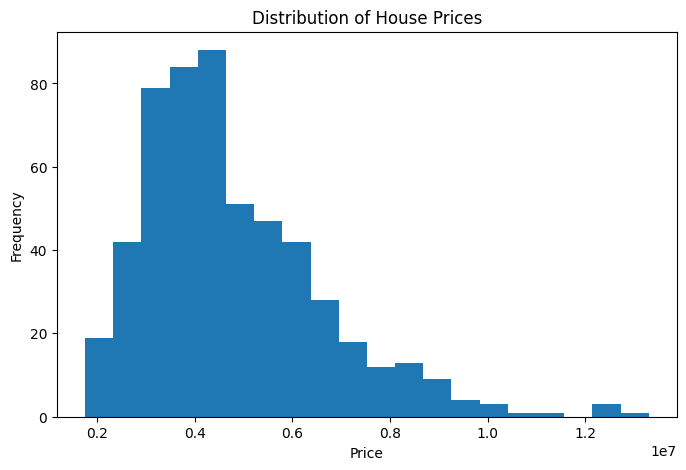

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=20)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("chart1_price_distribution.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

## Chart 2: Correlation Heatmap

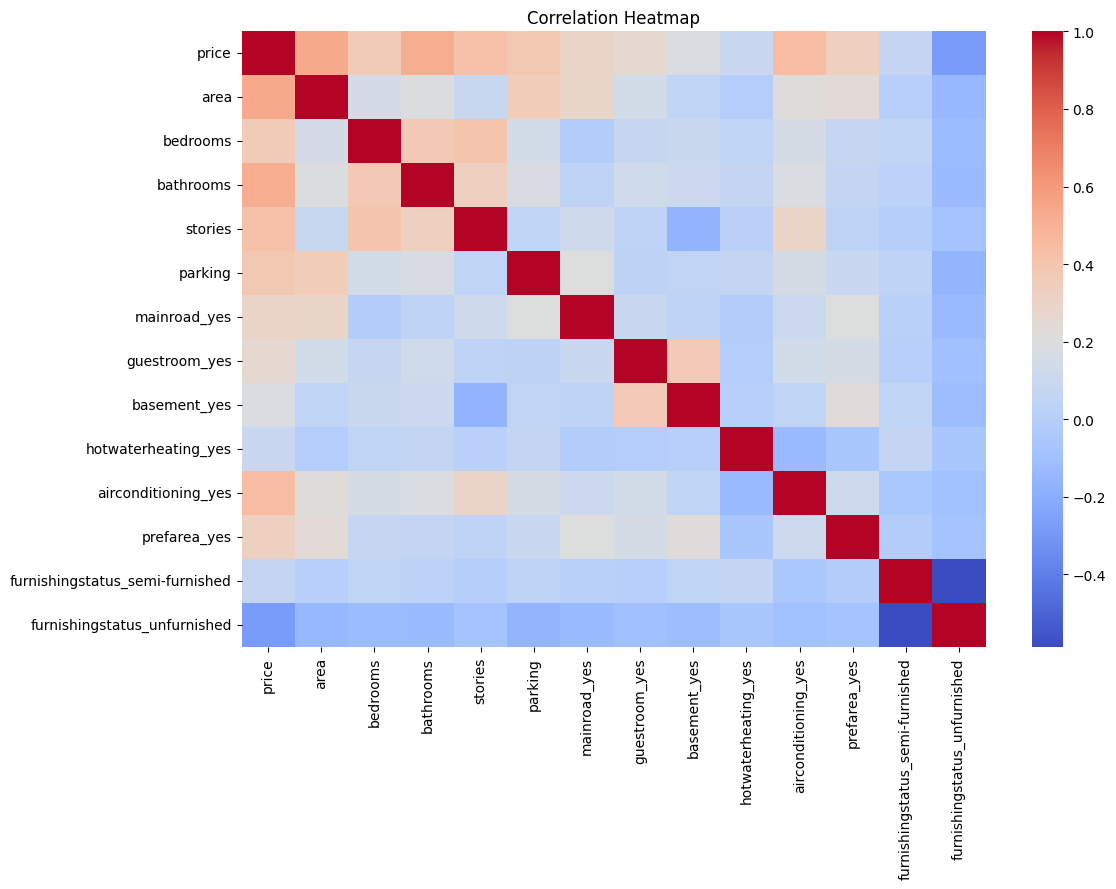

In [5]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(
    df_encoded.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.savefig("chart2_correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

## Chart 3: Actual vs Predicted Prices

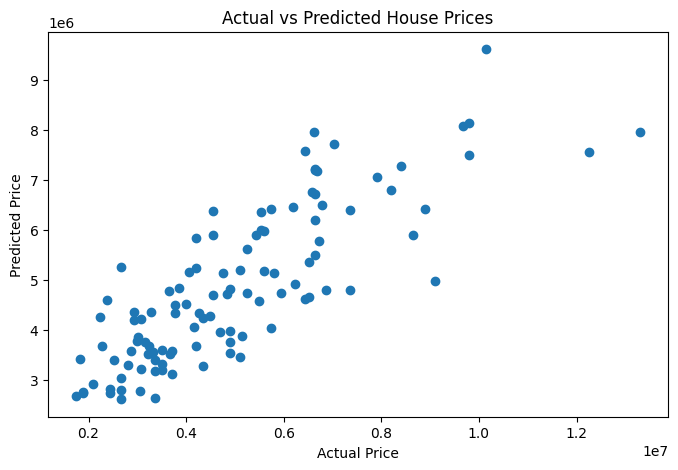

In [6]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.savefig("chart3_price_vs_area.png", dpi=300, bbox_inches='tight')

plt.show()

## Feature Importance (Random Forest)

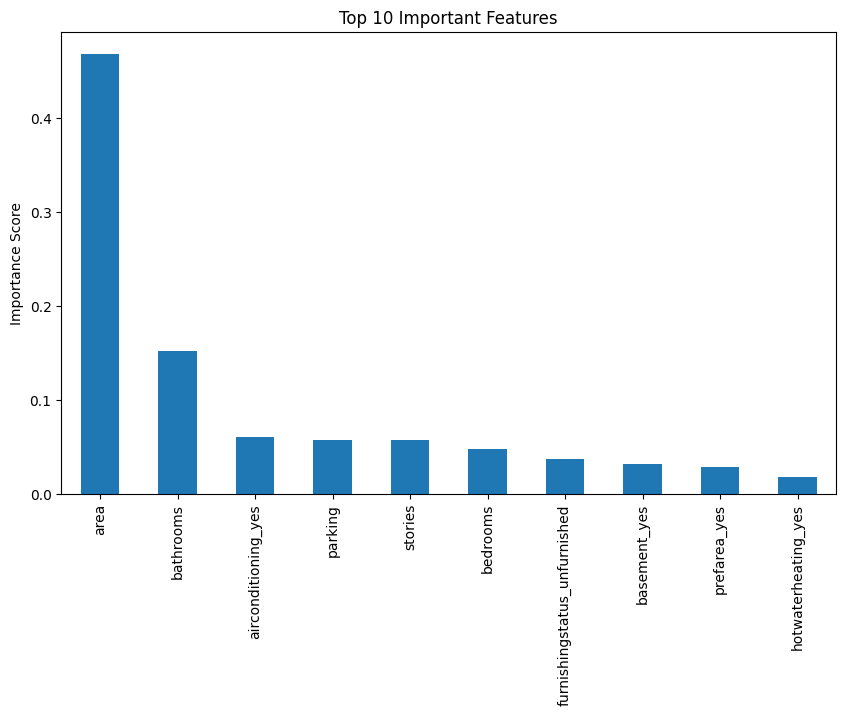

In [7]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.head(10).plot(kind='bar')

plt.title('Top 10 Important Features')
plt.ylabel('Importance Score')
plt.savefig("chart7_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

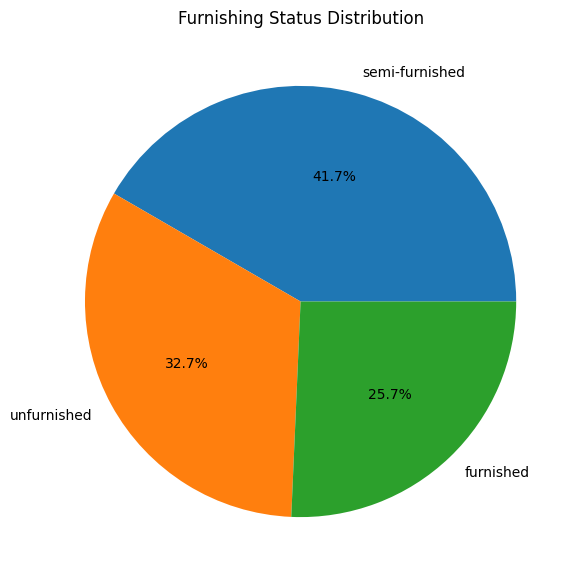

In [8]:
## Furnishing Status Distribution (Pie Chart)
plt.figure(figsize=(7,7))

df['furnishingstatus'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Furnishing Status Distribution')
plt.ylabel('')

plt.savefig("chart4_furnishing_status_pie.png", dpi=300, bbox_inches='tight')
plt.show()

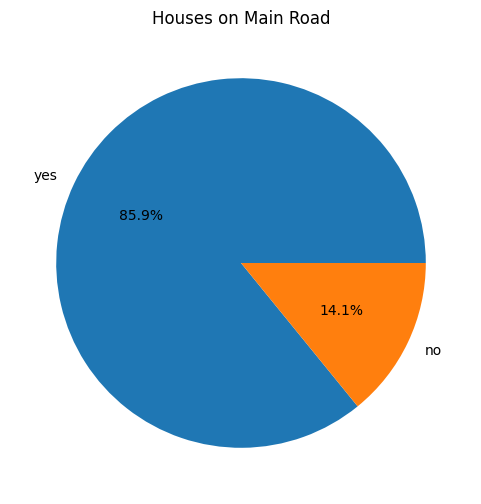

In [9]:
## Main Road Access (Pie Chart)
plt.figure(figsize=(6,6))

df['mainroad'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Houses on Main Road')
plt.ylabel('')

plt.savefig("chart5_mainroad_pie.png", dpi=300, bbox_inches='tight')
plt.show()

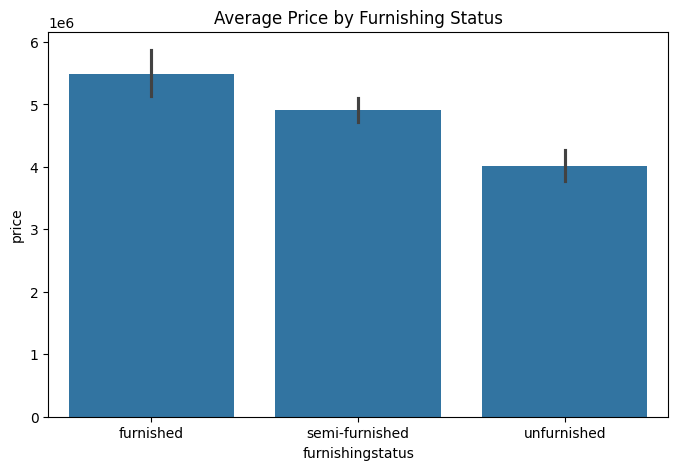

In [10]:
## Average Price by Furnishing Status (Bar Chart)
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='furnishingstatus',
    y='price'
)

plt.title('Average Price by Furnishing Status')
plt.savefig("chart6_Average Price by Furnishing_Bar_chart.png", dpi=300, bbox_inches='tight')
plt.show()

## Insights & Summary
### The analysis showed that area, bathrooms, parking availability, number of stories, and air conditioning have the strongest influence on house prices. The Linear Regression model achieved an R² score of approximately 0.65, meaning it can explain about 65% of the variation in house prices, which indicates reasonably good predictive performance. Surprisingly, the Random Forest model did not outperform Linear Regression on this dataset, suggesting that the relationships between features and price are mostly linear. The feature importance analysis revealed that house area is by far the most important factor affecting price. A useful recommendation for a real estate business would be to focus marketing efforts on larger houses with more bathrooms, parking spaces, and modern amenities such as air conditioning, as these characteristics contribute significantly to higher property values.

###  Top Important Features (Random Forest)
## Area
## Bathrooms
## Air Conditioning
## Parking
## Stories
## Bedrooms
## Basement
## Preferred Area